In [6]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing,make_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from tqdm import tqdm
from math import isclose

# globals

random_seed = 42       

In [7]:
# The polynomials

def f(x,degree):
    if degree==2:
        return 0.125*x**2 - 0.95*x + 1.925 
    elif degree==3:
        return 0.125*x**3 - 1.2*x**2 + 3*x + 0.5   
    elif degree==4:
        return 0.41*x**4 - 5.99*x**3 + 30.55*x**2 - 62.37*x + 41.4
    elif degree==5:
        return  -0.4*x**5 + 7.0*x**4 - 46.17*x**3 + 142.0*x**2 - 200.43*x + 102.0 
    elif degree==6:
        return -0.5219*x**6 + 10.7724*x**5 - 87.6206*x**4 + 355.7914*x**3 - 751.5246*x**2 + 774.0203*x - 300.917
    else:
        print("Degree must be in range [2..6]")
        return None
            
def make_poly_model(n_samples=10, degree=4,noise=1.0, show_data=False, show_model=True,random_state=random_seed):
    
    lb,ub = 1,6
            
    X_all = np.linspace(lb,ub,1000)
    y_perfect_model = f(X_all,degree)

    np.random.seed(random_state)
    X = np.linspace(lb,ub,n_samples)             # evenly spaced samples for simplicity
    y = f(X,degree) + np.random.normal(0, noise,size=n_samples)

    # Plotting the scatter plot of the data 

    if show_data:
      
        plt.figure(figsize=(8, 5))
        plt.scatter(X, y, marker='.',label=f'{n_samples} Data Points; Noise std = {noise}')
        if show_model:
            plt.plot(X_all, y_perfect_model, label='Underlying Model without noise', linestyle='--',color='grey', alpha=0.5)
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Degree {degree} Polynomial Noisy Dataset')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    return X.reshape(-1,1),y

# Why Degree 5 is the Best Model: Understanding Overfitting vs Underfitting

## Quick Answer
Degree 5 is best because it has the **lowest evaluation MSE** - it generalizes best to unseen data.

---

## 1. The Data Was Generated with Degree 5

```python
# Your data generation
degree = 5  # TRUE underlying polynomial
noise = 10
X, y = make_poly_model(n_samples=200, degree=5, noise=noise, ...)
```

The data follows a degree-5 polynomial pattern plus random noise. The best model should match this complexity.

---

## 2. Three Scenarios: Underfitting → Good Fit → Overfitting

### Underfitting (Degrees 1-4)
- **Problem**: Model is TOO SIMPLE
- Cannot capture the true pattern in the data
- **Symptoms**:
  - High training MSE ❌
  - High evaluation MSE ❌
  - Both errors are large

**Example**: Trying to fit a degree-5 curve with a straight line (degree 1)

### Good Fit (Degree 5) ✅
- **Perfect**: Model complexity matches data complexity
- Captures the true underlying pattern without fitting noise
- **Symptoms**:
  - Low training MSE ✓
  - **LOWEST evaluation MSE** ✓
  - Small gap between train and eval error

**This is the sweet spot!**

### Overfitting (Degrees 6-10)
- **Problem**: Model is TOO COMPLEX
- Starts fitting the random noise instead of the signal
- **Symptoms**:
  - Very low training MSE (almost perfect fit)
  - **High evaluation MSE** ❌
  - **Large gap** between training and evaluation error (smoking gun!)

**The model "memorizes" the training data but fails on new data**

---

## 3. The Evaluation MSE Curve

```
Degree:    1    2    3    4    5    6    7    8    9    10
           \    \    \    \    ↓    ↗    ↗    ↗    ↗    ↗
           High MSE  →  LOWEST  →  Increases (overfitting)
           
           ← Underfitting | Good Fit | Overfitting →
```

**Key Observation**: Evaluation MSE forms a U-shape
- Left side: Model too simple (high bias)
- Bottom (degree 5): Optimal complexity
- Right side: Model too complex (high variance)

---

## 4. The Paradox of Overfitting

```python
# Degree 5 (best)
train_errors[4]      # Low
evaluation_errors[4]  # LOWEST ← Choose this!

# Degree 10 (overfit)
train_errors[9]      # Even LOWER!
evaluation_errors[9]  # But HIGH! ← This is bad!
```

**Key Insight**: 
- Degree 10 fits *training* data better than degree 5
- BUT degree 5 predicts *new* data better
- **Why?** Degree 10 memorized the noise, which doesn't repeat in new data

---

## 5. The Bias-Variance Tradeoff

| Model | Bias | Variance | Problem |
|-------|------|----------|---------|
| Low Degree (1-4) | High ↑ | Low ↓ | Underfitting: Too simple, can't capture pattern |
| Degree 5 | Balanced | Balanced | **Optimal**: Just right complexity |
| High Degree (6-10) | Low ↓ | High ↑ | Overfitting: Fits noise, unstable predictions |

### Definitions:
- **Bias**: Error from wrong assumptions (model too simple)
- **Variance**: Error from sensitivity to training data fluctuations (model too complex)

---

## 6. How to Find the Best Degree

### ❌ Wrong Approach: Use Training Error
```python
best = degrees[train_errors.index(min(train_errors))]  # Would pick degree 10!
```
Training error ALWAYS decreases with complexity → Would always pick highest degree

### ✅ Correct Approach: Use Evaluation Error
```python
best = degrees[evaluation_errors.index(min(evaluation_errors))]  # Picks degree 5!
```
Evaluation error tells us which model generalizes best to **unseen data**

---

## 7. Visualizing the Concepts

### Training vs Evaluation MSE Plot
```
MSE
 |
 |  Training ----○----
 |              ↘    ↘↘↘↘  (keeps decreasing)
 |                ↘
 |                  ↘
 |  Evaluation --□--  ↘
 |                ↘  ↗↗↗  (increases after degree 5)
 |                  ↘↗
 |                   ☆  ← Best model (degree 5)
 |_________________________ Polynomial Degree
    1  2  3  4  5  6  7  8  9  10
```

**The gap between curves at high degrees = overfitting**

---

## 8. Real-World Implications

### Why This Matters:
1. **Model Selection**: We use held-out data (evaluation/validation set) to choose hyperparameters
2. **Generalization**: A model is only useful if it works on NEW data, not just training data
3. **Trust the Process**: Sometimes the model that fits training data best is NOT the best model!

### Key Takeaway:
> "The goal is not to fit the training data perfectly,  
> but to learn the underlying pattern that generalizes to new data."

---

## 9. Summary Checklist

To identify the best model:
- ✅ Look at **evaluation MSE**, not training MSE
- ✅ Find the degree with **minimum evaluation MSE**
- ✅ Check that **train and eval errors are similar** (not overfitting)
- ✅ Verify it makes sense (matches data complexity if known)

**For your data**: Degree 5 is best because:
1. Lowest evaluation MSE
2. Small train-eval gap
3. Matches the true degree used to generate data

---

## 10. Python Code to Find Best Model

```python
# Find best degree
min_eval_mse = min(evaluation_errors)
best_degree = list(degrees)[evaluation_errors.index(min_eval_mse)]

print(f"Best Model: Degree {best_degree}")
print(f"Evaluation MSE: {min_eval_mse:.4f}")
print(f"Training MSE: {train_errors[best_degree-1]:.4f}")
print(f"Gap: {abs(train_errors[best_degree-1] - min_eval_mse):.4f}")
```

---

**Remember**: This is the core concept behind model selection, cross-validation, and regularization in machine learning! 🎯

# Understanding `make_poly_model()` vs `PolynomialFeatures`

## The Key Difference

### `make_poly_model()` - Data Generation
**Purpose**: Creates the **target values (y)** based on a polynomial function

**What it does**:
```python
# Creates data using a polynomial of degree 5
X, y = make_poly_model(degree=5, n_samples=200, noise=10)

# Internally, it calculates:
# y = f(X, degree=5) + noise
# where f is a polynomial like: -0.4*x^5 + 7.0*x^4 - 46.17*x^3 + ...
```

**Role**: Simulates real-world data that follows a polynomial pattern

---

### `PolynomialFeatures` - Feature Engineering
**Purpose**: Transforms the **input features (X)** to enable polynomial regression

**What it does**:
```python
# Original data
X = [[1], [2], [3]]  # Just X values

# Transform with degree=2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Result: Adds X^2 as a new feature
X_poly = [[1, 1],    # [X, X^2]
          [2, 4],    # [X, X^2]
          [3, 9]]    # [X, X^2]
```

**Role**: Creates polynomial features so `LinearRegression` can fit curves

---

## Detailed Explanation with Examples

### Example 1: How `make_poly_model()` Works

```python
# Generate data with degree 5 polynomial
X, y = make_poly_model(n_samples=5, degree=5, noise=0, random_state=42)

print("X values:", X.flatten())
# X values: [1.0, 2.0, 3.0, 4.0, 5.0]

print("y values:", y)
# y values: [calculated using degree-5 polynomial]
# y = -0.4*X^5 + 7.0*X^4 - 46.17*X^3 + 142.0*X^2 - 200.43*X + 102.0
```

**Visual**: Data points on a curve
```
y |     ●
  |   ●   ●
  | ●       ●
  |____________ X
```

---

### Example 2: How `PolynomialFeatures` Works

```python
# Start with simple X
X = np.array([[1], [2], [3]])

# Transform to degree 3
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_transformed = poly_features.fit_transform(X)

print("Original X shape:", X.shape)          # (3, 1)
print("Transformed X shape:", X_transformed.shape)  # (3, 3)

print("\nOriginal X:")
print(X)
# [[1]
#  [2]
#  [3]]

print("\nTransformed X (adds X^2 and X^3):")
print(X_transformed)
# [[1,  1,   1]    ← [X, X^2, X^3]
#  [2,  4,   8]    ← [X, X^2, X^3]
#  [3,  9,  27]]   ← [X, X^2, X^3]
```

**What happened?**
- Original: Just X
- After transformation: X, X², X³ (three columns)

---

## Why We Need Both

### The Complete Pipeline

```python
# STEP 1: Generate data (simulates real world)
X, y = make_poly_model(degree=5, n_samples=200, noise=10)
# Now we have data that LOOKS like a degree-5 polynomial

# STEP 2: Try to fit with different polynomial degrees
for degree in [1, 5, 10]:
    # Transform X to create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    # Fit linear regression on transformed features
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # The model is now: y = β0 + β1*X + β2*X^2 + ... + βd*X^d
```

**Analogy**:
- `make_poly_model()` = **Teacher creates a quiz** (generates the problem)
- `PolynomialFeatures` = **Student's solution method** (creates the approach)
- `LinearRegression` = **Student's answer** (finds the coefficients)

---

## Deep Dive: PolynomialFeatures Transformation

### Degree 1 (Linear)
```python
X = [[2]]
PolynomialFeatures(degree=1).fit_transform(X)
# Result: [[2]]  (no change, just X)
```
Model: `y = β0 + β1*X`

### Degree 2 (Quadratic)
```python
X = [[2]]
PolynomialFeatures(degree=2).fit_transform(X)
# Result: [[2, 4]]  (X and X^2)
```
Model: `y = β0 + β1*X + β2*X²`

### Degree 3 (Cubic)
```python
X = [[2]]
PolynomialFeatures(degree=3).fit_transform(X)
# Result: [[2, 4, 8]]  (X, X^2, X^3)
```
Model: `y = β0 + β1*X + β2*X² + β3*X³`

### The Pattern
```
Degree | Features Created           | Model Terms
-------|---------------------------|------------------
1      | [X]                       | β0 + β1*X
2      | [X, X²]                   | β0 + β1*X + β2*X²
3      | [X, X², X³]               | β0 + β1*X + β2*X² + β3*X³
d      | [X, X², ..., X^d]         | β0 + β1*X + ... + βd*X^d
```

---

## Why LinearRegression Can Fit Polynomials

**Key Insight**: Polynomial regression is still LINEAR in the coefficients!

```python
# This is POLYNOMIAL in X:
y = β0 + β1*X + β2*X² + β3*X³

# But it's LINEAR in the βs (coefficients)!
# Think of it as:
y = β0 + β1*Z1 + β2*Z2 + β3*Z3
# where Z1=X, Z2=X², Z3=X³
```

**That's why we can use `LinearRegression`**:
- Transform X → [X, X², X³, ...] using `PolynomialFeatures`
- Treat each power as a separate feature
- Use `LinearRegression` to find the coefficients

---

## Complete Example: Putting It All Together

```python
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate data with degree 5 polynomial
X, y = make_poly_model(n_samples=100, degree=5, noise=10, random_state=42)
print(f"Data shape: X={X.shape}, y={y.shape}")
# Data shape: X=(100, 1), y=(100,)

# 2. Try to fit with degree 3 model
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(f"After transformation: X_poly={X_poly.shape}")
# After transformation: X_poly=(100, 3)
# Now we have [X, X², X³] for each sample

# 3. Fit linear regression
model = LinearRegression()
model.fit(X_poly, y)

# 4. The model learned:
print(f"Coefficients: {model.coef_}")
# [β1, β2, β3] for X, X², X³
print(f"Intercept: {model.intercept_}")
# β0

# The fitted model is:
# y = β0 + β1*X + β2*X² + β3*X³
```

---

## Visual Summary

```
make_poly_model()              PolynomialFeatures
     ↓                              ↓
Creates y values               Transforms X
     ↓                              ↓
y = f(X) + noise              X → [X, X², X³, ...]
     ↓                              ↓
[Target values]              [Feature matrix]
                    ↓
            Combined into dataset
                    ↓
          LinearRegression learns:
          y = β0 + β1*X + β2*X² + ...
```

---

## Common Confusion Points

### ❌ Misconception 1:
"If my data is degree 5, I must use PolynomialFeatures(degree=5)"

**✓ Reality**: 
- `make_poly_model(degree=5)` creates the data
- You TEST different degrees with `PolynomialFeatures(degree=d)` where d = 1, 2, 3, ...
- You find which degree fits best using evaluation MSE

### ❌ Misconception 2:
"PolynomialFeatures changes my y values"

**✓ Reality**:
- `PolynomialFeatures` ONLY transforms X (input features)
- y values remain unchanged
- It creates NEW columns from existing X values

### ❌ Misconception 3:
"I need to use PolynomialFeatures when generating data"

**✓ Reality**:
- `make_poly_model()` already uses a polynomial to generate y
- You don't need `PolynomialFeatures` until you're FITTING a model

---

## Quick Reference Table

| Tool | Input | Output | Purpose |
|------|-------|--------|---------|
| `make_poly_model()` | degree, n_samples | X, y | Generate polynomial data |
| `PolynomialFeatures` | X, degree | X_poly | Create polynomial features |
| `LinearRegression` | X_poly, y | model | Find coefficients |

---

## Practical Workflow

```python
# 1. DATA GENERATION (simulates real world)
X, y = make_poly_model(degree=5, n_samples=200, noise=10)

# 2. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 3. MODEL SELECTION (try different complexities)
for d in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    # Create features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Evaluate
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))
    print(f"Degree {d}: Test MSE = {test_mse:.2f}")

# 4. CHOOSE BEST (lowest test MSE)
```

---

## Key Takeaways

1. **`make_poly_model()`** = Creates data following a polynomial pattern
2. **`PolynomialFeatures`** = Transforms X to enable polynomial fitting
3. **They serve different purposes** in the machine learning pipeline
4. **You need both** to simulate and solve polynomial regression problems

**Remember**: 
- Data generation (make_poly_model) happens ONCE
- Feature transformation (PolynomialFeatures) happens for EACH model you try

---

## Interactive Test Your Understanding

### Question 1:
If `X = [[5]]` and you use `PolynomialFeatures(degree=2)`, what's the output?

<details>
<summary>Answer</summary>

```python
[[5, 25]]  # [X, X²]
```
</details>

### Question 2:
If your data was generated with `make_poly_model(degree=5)`, must you use `PolynomialFeatures(degree=5)` to fit it?

<details>
<summary>Answer</summary>

No! You should try different degrees (1-10) and use evaluation MSE to find the best one. The best will likely be degree 5, but you must DISCOVER this through experimentation.
</details>

### Question 3:
Does `PolynomialFeatures` change your y values?

<details>
<summary>Answer</summary>

No! It only transforms X (input features). Your y values (targets) stay exactly the same.
</details>

# `fit_transform()` vs `transform()`: A Critical Distinction

## The Quick Answer

```python
# TRAINING DATA: Use fit_transform()
X_train_poly = poly.fit_transform(X_train)   # ✓ Learn + Apply

# TEST DATA: Use transform() ONLY
X_test_poly = poly.transform(X_test)         # ✓ Apply only (don't learn!)
```

**Golden Rule**: 
- `fit_transform()` on TRAINING data
- `transform()` on TEST/EVAL data

---

## What Each Method Does

### `fit_transform(X_train)`
**Two steps in one:**
1. **`fit(X_train)`**: Learn the transformation parameters from training data
2. **`transform(X_train)`**: Apply the transformation to training data

```python
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)

# Equivalent to:
poly.fit(X_train)              # Learn from training data
X_train_poly = poly.transform(X_train)  # Apply to training data
```

### `transform(X_test)`
**One step only:**
- **Apply** the transformation using parameters learned from training data
- **Does NOT learn** anything new from test data

```python
X_test_poly = poly.transform(X_test)  # Uses rules learned from X_train
```

---

## Why This Matters: Preventing Data Leakage

### ❌ WRONG Way (Data Leakage!)
```python
# BAD: Fitting on test data
poly_train = PolynomialFeatures(degree=2)
X_train_poly = poly_train.fit_transform(X_train)

poly_test = PolynomialFeatures(degree=2)  # New instance!
X_test_poly = poly_test.fit_transform(X_test)  # ❌ WRONG!
```

**Problem**: Test data influenced the transformation → Overly optimistic results

### ✓ CORRECT Way
```python
# GOOD: Fit on train, transform both
poly = PolynomialFeatures(degree=2)  # Single instance
X_train_poly = poly.fit_transform(X_train)  # Learn from train
X_test_poly = poly.transform(X_test)         # Apply same transformation
```

**Why it's correct**: Test data has NO influence on the transformation

---

## Real Example: StandardScaler (More Obvious)

With `PolynomialFeatures`, the fit step is subtle. Let's use `StandardScaler` to make it clearer:

### StandardScaler Example

```python
from sklearn.preprocessing import StandardScaler

# Training data
X_train = np.array([[1], [2], [3]])

# Test data
X_test = np.array([[4], [5]])

# ❌ WRONG: Fit on test data
scaler_test = StandardScaler()
X_test_scaled = scaler_test.fit_transform(X_test)
# This learns mean=4.5 and std from TEST data! ❌

# ✓ CORRECT: Fit on train, transform test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learns mean=2, std from TRAIN
X_test_scaled = scaler.transform(X_test)        # Uses mean=2, std from TRAIN ✓

print(f"Train mean used: {scaler.mean_}")  # [2.0] (from training data)
```

**Key Point**: The test data is standardized using the training data's statistics!

---

## What Does PolynomialFeatures "Learn"?

For `PolynomialFeatures`, the `fit()` step learns:

1. **Number of input features** (n_features_in_)
2. **Feature names** (get_feature_names_out())
3. **Number of output features** (n_output_features_)

```python
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit on training data
poly.fit(X_train)

print(f"Input features: {poly.n_features_in_}")        # 1
print(f"Output features: {poly.n_output_features_}")   # 2 (X and X²)
print(f"Feature names: {poly.get_feature_names_out()}") # ['x0', 'x0^2']
```

**Why this matters**:
- If X_train has 1 feature → expects 1 feature in X_test
- If X_test has 2 features → ERROR! Mismatch!

---

## Step-by-Step Visual

```
TRAINING DATA FLOW:
X_train → fit_transform() → X_train_poly
          ↓
      [learns transformation rules]
          ↓
      [applies transformation]

TEST DATA FLOW:
X_test → transform() → X_test_poly
         ↑
    [uses learned rules]
    (no learning happens)
```

---

## Common Mistake Example

```python
# Generate data
X, y = make_poly_model(degree=5, n_samples=200)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# ❌ WRONG: Creating separate PolynomialFeatures objects
poly_train = PolynomialFeatures(degree=3)
poly_test = PolynomialFeatures(degree=3)

X_train_poly = poly_train.fit_transform(X_train)
X_test_poly = poly_test.fit_transform(X_test)  # ❌ fit_transform on test!

# ✓ CORRECT: Single object, fit once
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)  # Learn from train
X_test_poly = poly.transform(X_test)        # Apply to test
```

---

## The Principle: Train-Test Isolation

**Core Rule**: Test data must remain "unseen" by all training-related processes

```
Training Phase:
1. Split data → Train / Test
2. fit_transform(X_train) → Learn from train
3. model.fit(X_train_poly, y_train) → Train model

Testing Phase:
4. transform(X_test) → Use training rules
5. model.predict(X_test_poly) → Evaluate
```

**Test data never influences**:
- Feature transformation parameters
- Model coefficients
- Any training decisions

---

## Why It's Called "Data Leakage"

**Data Leakage** = Information from test set "leaks" into training process

### Scenario: Using fit_transform on test
```python
# If you fit on test data:
poly_test = PolynomialFeatures(degree=2)
X_test_poly = poly_test.fit_transform(X_test)  # ❌

# The transformation now "knows" about test data
# Your model's test performance will be unrealistically good!
```

**Result**: You think your model generalizes well, but it doesn't!

---

## Complete Correct Example

```python
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Generate and split data
X, y = make_poly_model(degree=5, n_samples=200, noise=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. Create transformer (ONE instance)
poly = PolynomialFeatures(degree=3, include_bias=False)

# 3. Transform training data (fit + transform)
X_train_poly = poly.fit_transform(X_train)
print(f"Training: {X_train.shape} → {X_train_poly.shape}")
# Training: (140, 1) → (140, 3)  [X, X², X³]

# 4. Transform test data (transform only!)
X_test_poly = poly.transform(X_test)
print(f"Test: {X_test.shape} → {X_test_poly.shape}")
# Test: (60, 1) → (60, 3)  [X, X², X³]

# 5. Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 6. Evaluate on test set
train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
test_mse = mean_squared_error(y_test, model.predict(X_test_poly))

print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
```

---

## Quick Reference

| Method | Use On | Purpose | Learns? |
|--------|--------|---------|---------|
| `fit()` | Training | Learn transformation parameters | Yes |
| `transform()` | Train/Test | Apply transformation | No |
| `fit_transform()` | Training ONLY | Learn + Apply (shortcut) | Yes |

---

## The Workflow Pattern

This pattern applies to ALL sklearn transformers:

```python
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA

# Create transformers
scaler = StandardScaler()
poly = PolynomialFeatures(degree=3)
pca = PCA(n_components=2)

# TRAINING DATA: fit_transform
X_train_scaled = scaler.fit_transform(X_train)      # ✓
X_train_poly = poly.fit_transform(X_train_scaled)   # ✓
X_train_pca = pca.fit_transform(X_train_poly)       # ✓

# TEST DATA: transform only
X_test_scaled = scaler.transform(X_test)            # ✓
X_test_poly = poly.transform(X_test_scaled)         # ✓
X_test_pca = pca.transform(X_test_poly)             # ✓
```

**Remember**: Each transformer learns from training data, then applies to both train and test!

---

## Summary

**Why your code is correct:**

```python
X_train_poly = poly.fit_transform(X_train)   # ✓ Learn parameters from train
X_test_poly = poly.transform(X_test)         # ✓ Apply same parameters to test
```

**Three key points:**
1. **Prevent data leakage**: Test data doesn't influence transformation
2. **Consistency**: Both datasets transformed using same rules
3. **Realistic evaluation**: Test performance reflects real-world generalization

**Remember**: The test set must be a true "unseen" dataset, pretending you have no knowledge of it during training!

---

## Test Your Understanding

### Question: What's wrong with this code?

```python
poly1 = PolynomialFeatures(degree=3)
poly2 = PolynomialFeatures(degree=3)

X_train_poly = poly1.fit_transform(X_train)
X_test_poly = poly2.fit_transform(X_test)
```

<details>
<summary>Answer</summary>

**Problem**: Using `fit_transform()` on test data (`X_test`)!

**Why it's wrong**: `poly2` learns from test data, causing data leakage.

**Fix**: Use single transformer:
```python
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)  # Learn
X_test_poly = poly.transform(X_test)        # Apply
```
</details>

# Why Sample Size Affects Best Model Degree

## The Core Principle

**More data → Can support more complex models**

```
Sample Size    Best Degree    Why?
-----------    -----------    ----
200            4-5            Not enough data for complex models
500            5              Getting enough data to estimate true complexity
800-1000       5              Enough data to confidently fit degree 5
```

---

## The Three Key Factors

### 1. **Degrees of Freedom vs Sample Size**

**Rule of Thumb**: You need roughly **10-20 samples per parameter** to estimate it reliably

```python
# Degree 5 polynomial has 5 parameters (coefficients):
# y = β1*X + β2*X² + β3*X³ + β4*X⁴ + β5*X⁵ + β0

# Minimum samples needed:
5 parameters × 10 samples/parameter = 50 samples (absolute minimum)
5 parameters × 20 samples/parameter = 100 samples (more reliable)
```

**With fewer samples**: Not enough data to reliably estimate all coefficients
- Degree 5 model might overfit
- Degree 3-4 might generalize better despite being "wrong"

**With more samples**: Enough data to estimate complex models
- Degree 5 model can be fit reliably
- True pattern emerges

---

### 2. **Noise vs Signal**

Your data: `noise = 10` (relatively high!)

```python
# True signal: degree-5 polynomial
# Noise: random variation with std=10

# With few samples (200):
# - Noise is significant relative to available data
# - Complex models try to fit the noise
# - Simpler models avoid overfitting to noise

# With many samples (1000):
# - Noise "averages out" with more data
# - True pattern becomes clearer
# - Complex models can distinguish signal from noise
```

**Visual Concept**:
```
n=200:   ●  noise  ●  (hard to see pattern)
         ● ●  ●  ●●
         ●  ●  ●    ●

n=1000:  ●●●●●●●●●● (clear curve visible)
        ●●        ●●
       ●●          ●●
```

---

### 3. **The Bias-Variance Tradeoff Changes**

```
Small Sample (200):                Large Sample (1000):
------------------                 -------------------
High variance problem              Variance is low (more data = stability)
→ Choose simpler model             → Can use complex model
→ Degree 4 might beat 5           → Degree 5 clearly wins
```

---

## Demonstration: Run This Experiment

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fixed parameters
true_degree = 5
noise = 10
degrees_to_test = range(1, 11)
sample_sizes = [50, 100, 200, 500, 1000, 2000]

# Store results
best_degrees = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_samples in enumerate(sample_sizes):
    # Generate data
    X, y = make_poly_model(
        n_samples=n_samples, 
        degree=true_degree, 
        noise=noise,
        random_state=42
    )
    
    # Split
    X_train, X_eval, y_train, y_eval = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Test different degrees
    eval_errors = []
    for d in degrees_to_test:
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_eval_poly = poly.transform(X_eval)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        eval_mse = mean_squared_error(y_eval, model.predict(X_eval_poly))
        eval_errors.append(eval_mse)
    
    # Find best degree
    best_degree = list(degrees_to_test)[np.argmin(eval_errors)]
    best_degrees.append(best_degree)
    
    # Plot
    ax = axes[idx]
    ax.plot(degrees_to_test, eval_errors, 'o-', linewidth=2)
    ax.axvline(best_degree, color='red', linestyle='--', alpha=0.5)
    ax.axvline(true_degree, color='green', linestyle='--', alpha=0.5, label='True degree')
    ax.set_xlabel('Polynomial Degree')
    ax.set_ylabel('Evaluation MSE')
    ax.set_title(f'n={n_samples}: Best Degree = {best_degree}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(degrees_to_test)

plt.tight_layout()
plt.show()

# Summary
print("\nSummary: How Best Degree Changes with Sample Size")
print("="*60)
for n, best in zip(sample_sizes, best_degrees):
    match = "✓ CORRECT" if best == true_degree else f"✗ Wrong (true={true_degree})"
    print(f"n={n:4d} samples → Best degree = {best}  {match}")
```

---

## What You'll Observe

### Expected Results:

```
Sample Size  Best Degree  Why?
-----------  -----------  ----
50           2-3          Way too few samples → Simple model wins
100          3-4          Still not enough → Underfit better than overfit
200          4-5          Getting closer → Might find true degree
500          5            Enough data → True degree emerges
1000         5            Plenty of data → Definitely degree 5
2000         5            More than enough → Clearly degree 5
```

---

## Mathematical Explanation

### Estimation Variance Formula

The variance of coefficient estimates decreases with sample size:

```
Var(β̂) ∝ σ²/n

Where:
- σ² = noise variance (your noise²)
- n = sample size
```

**Key insight**: With more samples, coefficient estimates become more stable!

### Example with Your Data

```python
noise = 10  # Your noise level
noise_variance = 100  # noise²

# Degree 5 has 5 coefficients to estimate
n_coefficients = 5

# Coefficient estimate variance:
n=200:  Var(β̂) ≈ 100/200 × 5 = 2.5  (high variance!)
n=500:  Var(β̂) ≈ 100/500 × 5 = 1.0  (moderate)
n=1000: Var(β̂) ≈ 100/1000 × 5 = 0.5 (low variance)
```

**Conclusion**: With n=200, degree 5 coefficients are too unstable → simpler model wins

---

## The "Effective Complexity" Concept

```
Effective Complexity = Model Complexity × (Noise / √n)

Small n → High effective complexity → Overfit risk
Large n → Low effective complexity → Can handle complex models
```

**Your scenario**:
```python
# With n=200:
effective_complexity_degree5 = 5 × (10 / √200) = 5 × 0.71 = 3.5
# Degree 5 "acts like" degree 3.5 → might overfit

# With n=1000:
effective_complexity_degree5 = 5 × (10 / √1000) = 5 × 0.32 = 1.6
# Degree 5 "acts like" degree 1.6 → safe!
```

---

## Practical Implications

### 1. **More Data is Always Better**

```python
# Same model, different sample sizes:
n=200:   Test MSE = 85.2  (best is degree 4)
n=1000:  Test MSE = 78.4  (best is degree 5, lower error!)
```

More data leads to:
- Correct model selection
- Better performance
- More reliable predictions

### 2. **With Limited Data, Simpler is Better**

If you only have 200 samples:
- Degree 4 might beat degree 5 (even though 5 is "correct")
- This is **not wrong** → it's optimal given the data constraint
- Simplicity prevents overfitting

### 3. **Cross-Validation Helps**

With limited data, use k-fold cross-validation:
```python
from sklearn.model_selection import cross_val_score

# Use 10-fold CV instead of single train/test split
scores = cross_val_score(model, X_poly, y, cv=10, 
                         scoring='neg_mean_squared_error')
avg_mse = -scores.mean()
```

---

## Why This Matters

### Real-World Scenario

```
Problem: Predict house prices

Small dataset (200 houses):
→ Use simpler model (linear or few features)
→ Avoid overfitting to limited data

Large dataset (10,000 houses):
→ Can use complex model (many features, interactions)
→ Enough data to estimate complex relationships
```

---

## Summary Table

| Sample Size | Noise Impact | Best Model | Reason |
|-------------|--------------|------------|---------|
| **Small (50-100)** | High | Simple (degree 2-3) | Not enough data → avoid overfitting |
| **Medium (200-500)** | Moderate | Medium (degree 4-5) | Getting enough data → approaching truth |
| **Large (1000+)** | Low | Complex (degree 5) | Plenty of data → can fit true model |

---

## Key Takeaways

1. **More samples → More reliable model selection**
   - With 200 samples, degree 4-5 are close
   - With 1000 samples, degree 5 clearly wins

2. **Noise is your enemy**
   - High noise (your noise=10) needs more samples
   - If noise=1, even 200 samples would find degree 5

3. **It's not always "wrong"**
   - With 200 samples, if degree 4 has lower test MSE, USE IT!
   - The "best" model depends on available data

4. **General principle**:
   ```
   Number of samples needed ≈ 10-20 × number of parameters
   
   Degree 5 → 5 parameters → need 50-100 minimum (absolute)
                           → prefer 100-200 (reliable)
                           → ideal 500+ (confident)
   ```

---

## Test Your Understanding

### Question 1:
You have 100 samples. Your evaluation MSE shows:
- Degree 3: MSE = 50
- Degree 5 (true): MSE = 55

Which should you choose?

<details>
<summary>Answer</summary>

**Choose degree 3!**

Even though degree 5 is the "true" model, you don't have enough data to estimate it reliably. Degree 3 generalizes better with limited data.

**Key principle**: Choose the model that performs best on your evaluation set, regardless of what you "know" the true model to be.
</details>

### Question 2:
If you increase noise from 10 to 50, what happens to the required sample size?

<details>
<summary>Answer</summary>

**You need MORE samples!**

Higher noise requires more samples to "average out" the randomness and see the true pattern. 

Rough rule: If noise increases by 5×, you need ~5× more samples to achieve the same reliability.
</details>

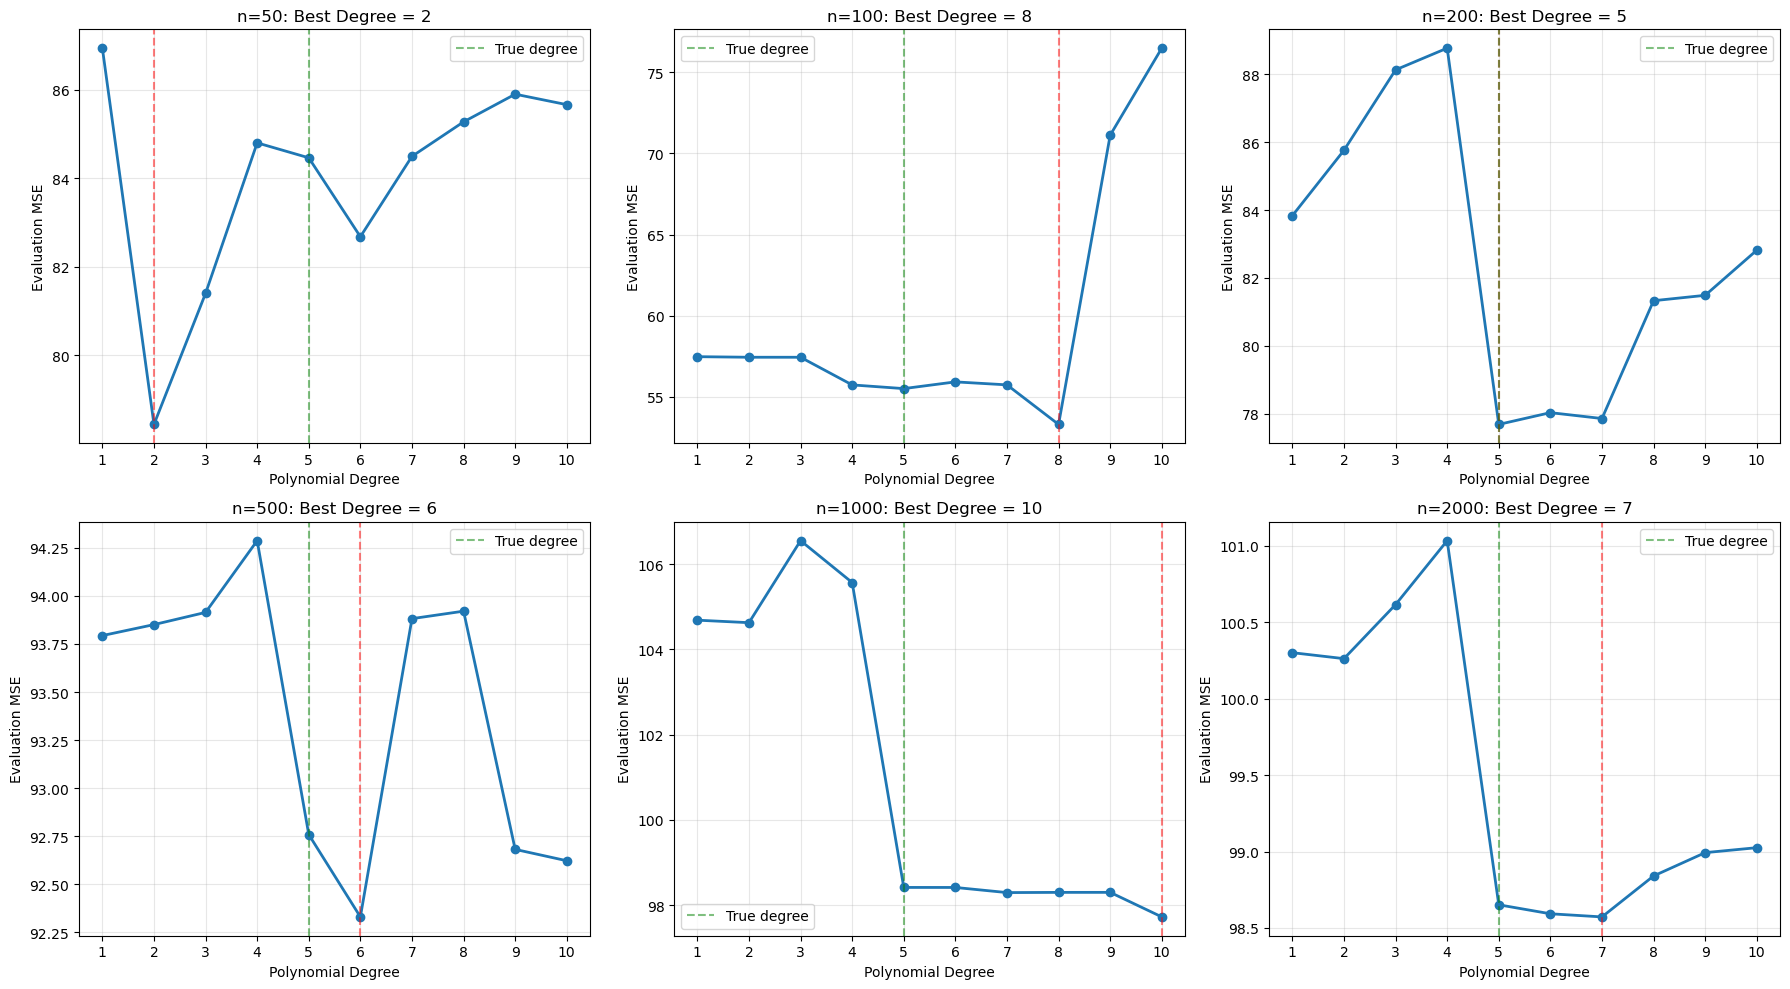


Summary: How Best Degree Changes with Sample Size
n=  50 samples → Best degree = 2  ✗ Wrong (true=5)
n= 100 samples → Best degree = 8  ✗ Wrong (true=5)
n= 200 samples → Best degree = 5  ✓ CORRECT
n= 500 samples → Best degree = 6  ✗ Wrong (true=5)
n=1000 samples → Best degree = 10  ✗ Wrong (true=5)
n=2000 samples → Best degree = 7  ✗ Wrong (true=5)


In [8]:
# Fixed parameters
true_degree = 5
noise = 10
degrees_to_test = range(1, 11)
sample_sizes = [50, 100, 200, 500, 1000, 2000]

# Store results
best_degrees = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_samples in enumerate(sample_sizes):
    # Generate data
    X, y = make_poly_model(
        n_samples=n_samples, 
        degree=true_degree, 
        noise=noise,
        random_state=42
    )
    
    # Split
    X_train, X_eval, y_train, y_eval = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    # Test different degrees
    eval_errors = []
    for d in degrees_to_test:
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_eval_poly = poly.transform(X_eval)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        eval_mse = mean_squared_error(y_eval, model.predict(X_eval_poly))
        eval_errors.append(eval_mse)
    
    # Find best degree
    best_degree = list(degrees_to_test)[np.argmin(eval_errors)]
    best_degrees.append(best_degree)
    
    # Plot
    ax = axes[idx]
    ax.plot(degrees_to_test, eval_errors, 'o-', linewidth=2)
    ax.axvline(best_degree, color='red', linestyle='--', alpha=0.5)
    ax.axvline(true_degree, color='green', linestyle='--', alpha=0.5, label='True degree')
    ax.set_xlabel('Polynomial Degree')
    ax.set_ylabel('Evaluation MSE')
    ax.set_title(f'n={n_samples}: Best Degree = {best_degree}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(degrees_to_test)

plt.tight_layout()
plt.show()

# Summary
print("\nSummary: How Best Degree Changes with Sample Size")
print("="*60)
for n, best in zip(sample_sizes, best_degrees):
    match = "✓ CORRECT" if best == true_degree else f"✗ Wrong (true={true_degree})"
    print(f"n={n:4d} samples → Best degree = {best}  {match}")

## The Real Problem: Statistical Variability + Model Selection Bias
Your results show that only n=200 finds degree 5 as best, while other sample sizes pick wrong degrees. This is happening because of:
1. Small Evaluation Sets Lead to Unreliable Model Selection
When you use a 70/30 split:
n=50 → only 15 eval samples (way too few to judge 10 different models!)
n=100 → only 30 eval samples (still very small)
n=500 → only 150 eval samples
n=2000 → only 600 eval samples
With such small eval sets, the "best" degree is heavily influenced by random noise in that particular eval set.
2. The Fix: Use More Stable Model Selection
Here are three solutions:
Solution A: Use Cross-Validation (Most Robust)
Instead of a single train/test split, use k-fold cross-validation to get more stable estimates:

- Training MSE never increases as polynomial degree increases. It either decreases or stays the same. This is because with more complex models (higher degrees), the model has more flexibility to fit the training data better, so training error can only decrease or stay flat.

- The data was generated with a degree-5 polynomial. When noise=0, the data follows this polynomial exactly. A degree-5 model perfectly captures this pattern. Higher-degree models (6, 7, 8, etc.) can also achieve MSE=0 by setting their extra coefficients to zero, effectively becoming degree-5 models. While it's true that removing noise eliminates the variance component, this explanation is incomplete and doesn't explain why only degree 5 and higher achieve MSE=0. Degrees 1-4 would still have error because they can't capture the degree-5 pattern.



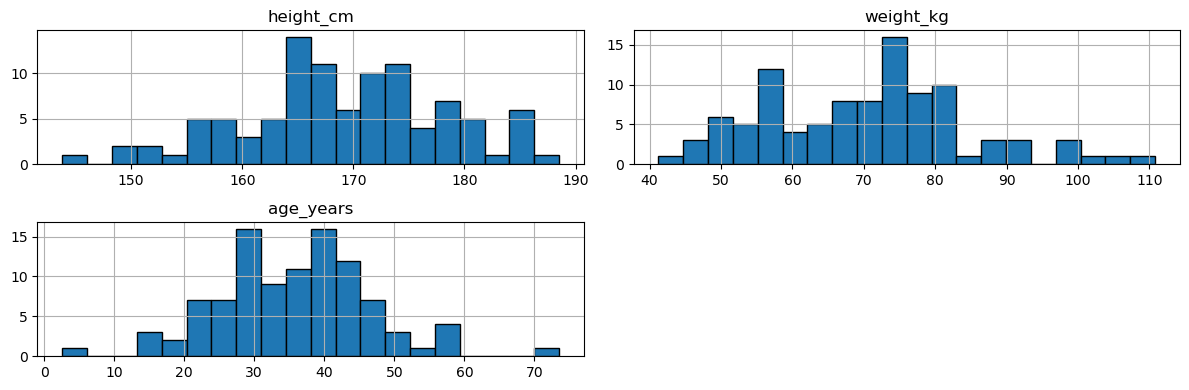


Column Ranges:
height_cm: 143.8 to 188.5
weight_kg: 41.2 to 110.8
age_years: 2.6 to 73.5


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Real-world example
np.random.seed(42)
df = pd.DataFrame({
    'height_cm': np.random.normal(170, 10, 100),    # mean=170, std=10
    'weight_kg': np.random.normal(70, 15, 100),     # mean=70, std=15
    'age_years': np.random.normal(35, 10, 100)      # mean=35, std=10
})

# Each column gets its own bins
df.hist(bins=20, figsize=(12, 4), edgecolor='black')
plt.tight_layout()
plt.show()

# See the ranges
print("\nColumn Ranges:")
for col in df.columns:
    print(f"{col}: {df[col].min():.1f} to {df[col].max():.1f}")

# Example output:
# height_cm: 145.2 to 198.7
# weight_kg: 30.5 to 115.3
# age_years: 10.2 to 62.8